In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [14]:
ruta = os.path.join("..", 'Data', 'INEMesesDeVisitasClean11022026.csv')
df_ine = pd.read_csv(ruta, sep=";")

ruta2 = os.path.join("..", 'Data', 'TouristAccommodationClean02022026.csv')
df = pd.read_csv(ruta2, sep=None, engine='python', encoding='latin1')

In [3]:
df_ine.columns 

Index(['Fecha', 'Total', 'Residentes en España', 'Residentes en el Extranjero',
       'Provincia', 'Código', 'Mes', 'Año'],
      dtype='object')

In [4]:
df_ine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Fecha                        240 non-null    object 
 1   Total                        240 non-null    object 
 2   Residentes en España         240 non-null    float64
 3   Residentes en el Extranjero  240 non-null    float64
 4   Provincia                    240 non-null    object 
 5   Código                       240 non-null    int64  
 6   Mes                          240 non-null    object 
 7   Año                          240 non-null    int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 15.1+ KB


In [5]:
df_ine.describe()

,Residentes en España,Residentes en el Extranjero,Código,Año
count,240.000000,240.000000,240.000000,240.000000
mean,122.139346,112.765029,25.300000,2020.500000
std,115.278337,151.049645,14.584109,0.501045
min,0.000000,0.000000,3.000000,2020.000000
25%,38.661250,19.573000,9.000000,2020.000000
50%,93.642500,53.488500,28.500000,2020.500000
75%,170.895000,141.000500,38.000000,2021.000000
max,602.000000,894.903000,46.000000,2021.000000


In [6]:
# Limpiar columnas numéricas (quitar puntos de miles y convertir a float)
for col in ['Total', 'Residentes en España', 'Residentes en el Extranjero']:
    df_ine[col] = df_ine[col].astype(str).str.replace('.', '', regex=False).astype(float)

# Fecha tipo periodo (ej. 2021M01 -> 2021-01-01)
df_ine['Fecha'] = pd.to_datetime(df_ine['Fecha'].str.replace('M','-') + '-01')

# Filtrar 2020–2021
df_ine = df_ine[(df_ine['Año'] >= 2020) & (df_ine['Año'] <= 2021)]

df_ine.rename(columns={
    'Residentes en España': 'INE_res_esp',
    'Residentes en el Extranjero': 'INE_res_ext',
    'Total': 'INE_total',
    'Provincia': 'provincia',
    'Código': 'cod_prov'
}, inplace=True)

df_ine.head()


,Fecha,INE_total,INE_res_esp,INE_res_ext,provincia,cod_prov,Mes,Año
0,2021-12-01,235138.0,142779.0,92359.0,Málaga,29,DIC,2021
1,2021-11-01,280935.0,137552.0,143382.0,Málaga,29,NOV,2021
2,2021-10-01,451642.0,186441.0,265201.0,Málaga,29,OCT,2021
3,2021-09-01,483297.0,247187.0,23611.0,Málaga,29,SEP,2021
4,2021-08-01,626297.0,405728.0,220569.0,Málaga,29,AGO,2021


In [7]:
# Porcentajes de ocupación de residentes españoles y extranjeros
df_ine['porc_res_esp'] = ((df_ine['INE_res_esp'] / df_ine['INE_total']) * 100).round(2)
df_ine['porc_res_ext'] = ((df_ine['INE_res_ext'] / df_ine['INE_total']) * 100).round(2)

# Media de ocupación por provincia (promedio histórico)
df_ine['media_ocup_provincia'] = (df_ine.groupby('provincia')['INE_total'].transform('mean')).round(2)

# Porcentaje respecto a la media provincial
df_ine['porc_vs_media_provincial'] = ((df_ine['INE_total'] / df_ine['media_ocup_provincia']) * 100).round(2)

# Desviación porcentual respecto a la media provincial: 
# La desviación te dice cuánto se aleja un valor de la media, expresado en porcentaje.
df_ine['desv_porc_media'] = (((df_ine['INE_total'] - df_ine['media_ocup_provincia']) / df_ine['media_ocup_provincia']) * 100).round(2)
#desv_porc_media= Malaga en Diciembre 2021 tiene el 7.5% mas de ocupacion que la media

df_ine.head()

,Fecha,INE_total,INE_res_esp,INE_res_ext,provincia,cod_prov,Mes,Año,porc_res_esp,porc_res_ext,media_ocup_provincia,porc_vs_media_provincial,desv_porc_media
0,2021-12-01,235138.0,142779.0,92359.0,Málaga,29,DIC,2021,60.72,39.28,218736.08,107.50,7.50
1,2021-11-01,280935.0,137552.0,143382.0,Málaga,29,NOV,2021,48.96,51.04,218736.08,128.44,28.44
2,2021-10-01,451642.0,186441.0,265201.0,Málaga,29,OCT,2021,41.28,58.72,218736.08,206.48,106.48
3,2021-09-01,483297.0,247187.0,23611.0,Málaga,29,SEP,2021,51.15,4.89,218736.08,220.95,120.95
4,2021-08-01,626297.0,405728.0,220569.0,Málaga,29,AGO,2021,64.78,35.22,218736.08,286.33,186.33


Para saber cual es la tendencia de los 12 meses del 2020

In [8]:
# Mapear meses a estaciones
estaciones = {
    'Enero': 'Invierno', 'Febrero': 'Invierno', 'Marzo': 'Primavera',
    'Abril': 'Primavera', 'Mayo': 'Primavera', 'Junio': 'Verano',
    'Julio': 'Verano', 'Agosto': 'Verano', 'Septiembre': 'Otoño',
    'Octubre': 'Otoño', 'Noviembre': 'Otoño', 'Diciembre': 'Invierno'
}

df_ine['Estacion'] = df_ine['Mes'].map(estaciones)

In [9]:
df_2020 = df_ine[df_ine['Año'] == 2020].copy()

In [10]:
# Ocupación promedio por estación
tendencia_estaciones = df_2020.groupby('Estacion').agg({
    'INE_total': ['mean', 'sum', 'count'],
    'INE_res_esp': 'mean',
    'INE_res_ext': 'mean'
}).round(2)

In [11]:
# PASO 1: Limpiar espacios en blanco de la columna Mes
df_ine['Mes'] = df_ine['Mes'].str.strip()

# PASO 2: Mapear meses abreviados a estaciones
estaciones_map = {
    'ENE': 'Invierno', 'FEB': 'Invierno', 'MAR': 'Primavera',
    'ABR': 'Primavera', 'MAY': 'Primavera', 'JUN': 'Verano',
    'JUL': 'Verano', 'AGO': 'Verano', 'SEP': 'Otoño',
    'OCT': 'Otoño', 'NOV': 'Otoño', 'DIC': 'Invierno'
}

df_ine['Estacion'] = df_ine['Mes'].map(estaciones_map)

# PASO 3: Filtrar datos de 2020
df_2020 = df_ine[df_ine['Año'] == 2020].copy()

# PASO 4: Ordenar meses 
orden_meses = ['ENE', 'FEB', 'MAR', 'ABR', 'MAY', 'JUN', 
               'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']

# PASO 5: Ocupación promedio por mes
df_2020_monthly = df_2020.groupby('Mes')['INE_total'].mean().reindex(orden_meses)

print("📊 OCUPACIÓN PROMEDIO POR MES - 2020:")
print(df_2020_monthly.round(2))
print("\n")

# PASO 6: Cambio porcentual mes a mes
cambio_mensual = df_2020_monthly.pct_change(fill_method=None) * 100




📊 OCUPACIÓN PROMEDIO POR MES - 2020:
Mes
ENE    360147.0
FEB    404296.5
MAR    164488.8
ABR         0.0
MAY      3973.1
JUN     39106.2
JUL    201215.3
AGO    267383.9
SEP    155250.8
OCT    110879.3
NOV     70294.4
DIC     85597.1
Name: INE_total, dtype: float64




In [12]:

print("📈 CAMBIO PORCENTUAL MES A MES:")
print(cambio_mensual.round(2))
print("\n")

📈 CAMBIO PORCENTUAL MES A MES:
Mes
ENE       NaN
FEB     12.26
MAR    -59.31
ABR   -100.00
MAY       inf
JUN    884.27
JUL    414.54
AGO     32.88
SEP    -41.94
OCT    -28.58
NOV    -36.60
DIC     21.77
Name: INE_total, dtype: float64




In [13]:
# PASO 7: Resumen de tendencia
print("📋 RESUMEN DE TENDENCIA 2020:")
print(f"Mes con MAYOR ocupación: {df_2020_monthly.idxmax()} ({df_2020_monthly.max():,.0f})")
print(f"Mes con MENOR ocupación: {df_2020_monthly.idxmin()} ({df_2020_monthly.min():,.0f})")
diferencia_porc = ((df_2020_monthly.max() - df_2020_monthly.min()) / df_2020_monthly.min() * 100)
print(f"Diferencia: {diferencia_porc:.2f}%")
print("\n")

# PASO 8: Ocupación por estaciones
print("🌡️ OCUPACIÓN PROMEDIO POR ESTACIÓN:")
estaciones_orden = ['Invierno', 'Primavera', 'Verano', 'Otoño']
df_estaciones = df_2020.groupby('Estacion')['INE_total'].mean().reindex(estaciones_orden)
print(df_estaciones.round(2))

📋 RESUMEN DE TENDENCIA 2020:
Mes con MAYOR ocupación: FEB (404,296)
Mes con MENOR ocupación: ABR (0)


ZeroDivisionError: float division by zero

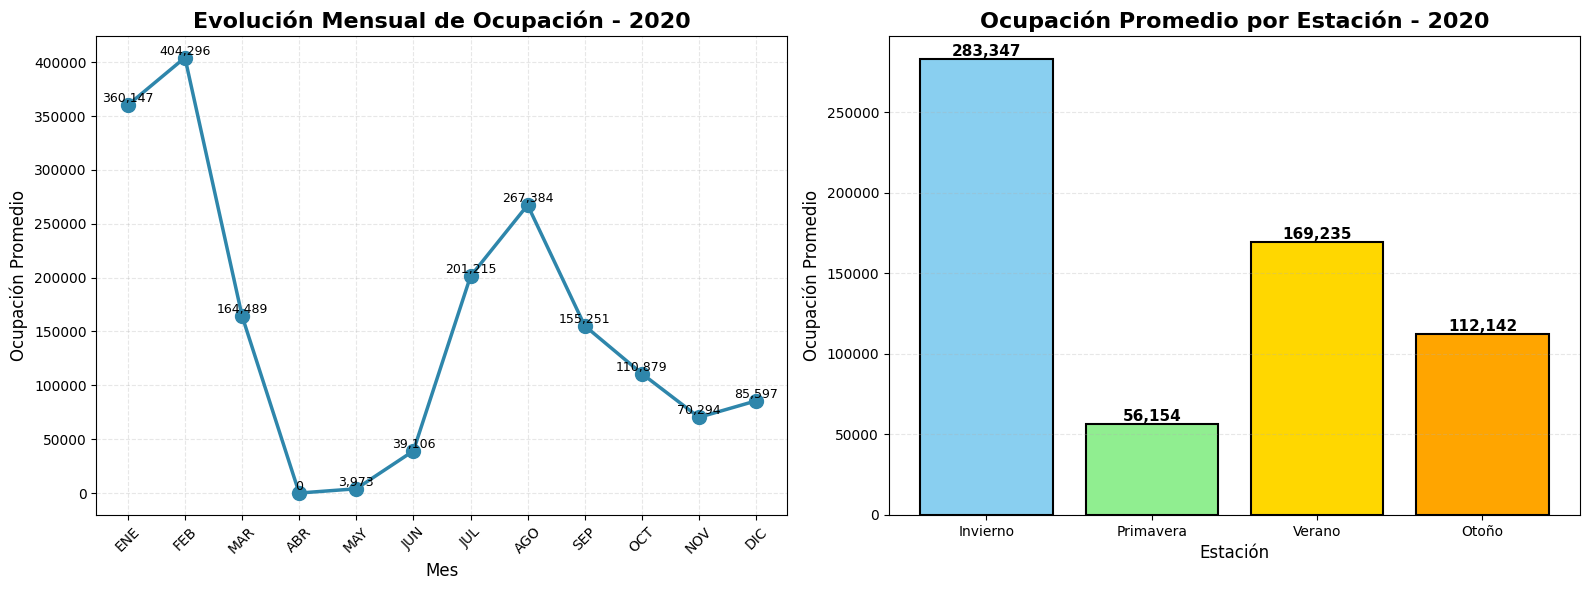

In [ ]:
# Crear figura con 2 gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Evolución mensual
ax1.plot(orden_meses, df_2020_monthly.values, marker='o', linewidth=2.5, markersize=10, color='#2E86AB')
ax1.set_title('Evolución Mensual de Ocupación - 2020', fontsize=16, fontweight='bold')
ax1.set_xlabel('Mes', fontsize=12)
ax1.set_ylabel('Ocupación Promedio', fontsize=12)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', rotation=45)

# Añadir valores sobre los puntos
for i, (mes, valor) in enumerate(zip(orden_meses, df_2020_monthly.values)):
    ax1.text(i, valor, f'{valor:,.0f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Ocupación por estación
colores = ['#89CFF0', '#90EE90', '#FFD700', '#FFA500']
bars = ax2.bar(estaciones_orden, df_estaciones.values, color=colores, edgecolor='black', linewidth=1.5)
ax2.set_title('Ocupación Promedio por Estación - 2020', fontsize=16, fontweight='bold')
ax2.set_xlabel('Estación', fontsize=12)
ax2.set_ylabel('Ocupación Promedio', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# Añadir valores sobre las barras
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Tendencias por ciudades

In [ ]:
# Comparar ocupación promedio entre 2020 y 2021
comparacion_años = df_ine.groupby(['provincia', 'Año'])['INE_total'].mean().unstack()
comparacion_años['Crecimiento_%'] = ((comparacion_años[2021] - comparacion_años[2020]) / comparacion_años[2020] * 100).round(2)
comparacion_años['Diferencia_Absoluta'] = (comparacion_años[2021] - comparacion_años[2020]).round(2)

# Ordenar por crecimiento
comparacion_años_sorted = comparacion_años.sort_values('Crecimiento_%', ascending=False)

print("📊 COMPARACIÓN DE OCUPACIÓN POR PROVINCIA (2020 vs 2021):")
print(comparacion_años_sorted)
print("\n")




📊 COMPARACIÓN DE OCUPACIÓN POR PROVINCIA (2020 vs 2021):
Año                              2020           2021  Crecimiento_%  \
provincia                                                             
Balears, Illes          118602.166667  423531.500000         257.10   
Málaga                  154647.666667  282824.500000          82.88   
Madrid                  298890.583333  522125.500000          74.69   
Barcelona               250603.416667  429290.500000          71.30   
Girona                  127287.166667  214623.750000          68.61   
Valencia/València       107003.916667  178872.833333          67.16   
Alicante/Alacant        135091.916667  225768.166667          67.12   
Sevilla                  93494.083333  150129.916667          60.58   
Santa Cruz de Tenerife  109461.833333  175042.333333          59.91   
Palmas, Las             157110.916667  247481.666667          57.52   

Año                     Diferencia_Absoluta  
provincia                                   

In [ ]:
# Top 5 provincias con mayor crecimiento
print("🚀 TOP 5 PROVINCIAS CON MAYOR CRECIMIENTO:")
print(comparacion_años_sorted.head(5)[['Crecimiento_%', 'Diferencia_Absoluta']])
print("\n")

# Top 5 provincias con menor crecimiento o decrecimiento
print("⚠️ TOP 5 PROVINCIAS CON MENOR CRECIMIENTO:")
comparacion_años_sorted.tail(5)[['Crecimiento_%', 'Diferencia_Absoluta']]

🚀 TOP 5 PROVINCIAS CON MAYOR CRECIMIENTO:
Año             Crecimiento_%  Diferencia_Absoluta
provincia                                         
Balears, Illes         257.10            304929.33
Málaga                  82.88            128176.83
Madrid                  74.69            223234.92
Barcelona               71.30            178687.08
Girona                  68.61             87336.58


⚠️ TOP 5 PROVINCIAS CON MENOR CRECIMIENTO:


Año,Crecimiento_%,Diferencia_Absoluta
provincia,,
Valencia/València,67.16,71868.92
Alicante/Alacant,67.12,90676.25
Sevilla,60.58,56635.83
Santa Cruz de Tenerife,59.91,65580.50
"Palmas, Las",57.52,90370.75


Analizando tendencias por temporada (estaciones)

In [ ]:
# Ver qué provincias tienen mejor comportamiento en cada estación
tendencia_estaciones = df_ine.groupby(['provincia', 'Estacion'])['INE_total'].mean().unstack(fill_value=0)

print("\n🌡️ OCUPACIÓN PROMEDIO POR PROVINCIA Y ESTACIÓN:")
print(tendencia_estaciones.round(2))

# Identificar provincias más equilibradas (menos estacionales)
tendencia_estaciones['Desv_Estandar'] = tendencia_estaciones.std(axis=1)
tendencia_estaciones['Coef_Variacion_%'] = (tendencia_estaciones['Desv_Estandar'] / tendencia_estaciones.mean(axis=1) * 100).round(2)

print("\n📈 PROVINCIAS MENOS ESTACIONALES (más estables):")
provincias_estables = tendencia_estaciones.sort_values('Coef_Variacion_%')[['Coef_Variacion_%', 'Desv_Estandar']].head(10)
print(provincias_estables)


🌡️ OCUPACIÓN PROMEDIO POR PROVINCIA Y ESTACIÓN:
Estacion                 Invierno      Otoño  Primavera     Verano
provincia                                                         
Alicante/Alacant        138399.33  206100.83   75095.17  302124.83
Balears, Illes           52105.00  350808.83   68202.33  613151.17
Barcelona               418569.83  398708.67  160025.50  382483.83
Girona                   85211.50  185976.17   62198.17  350436.00
Madrid                  561478.33  504316.83  225995.00  350242.00
Málaga                  173428.67  254619.83   84454.83  362441.00
Palmas, Las             248821.83  264876.00   80110.17  215377.17
Santa Cruz de Tenerife  181882.33  188475.00   60709.83  137941.17
Sevilla                 144467.67  155674.83   63514.67  123590.83
Valencia/València       132104.33  171285.50   65927.67  202436.00

📈 PROVINCIAS MENOS ESTACIONALES (más estables):
Estacion                Coef_Variacion_%  Desv_Estandar
provincia                                 

In [ ]:
# Ver qué provincias se recuperaron mejor después del confinamiento
meses_covid = ['ABR', 'MAY', 'JUN']  # Meses de confinamiento
meses_post_covid = ['JUL', 'AGO', 'SEP']  # Recuperación verano

df_2020_prov = df_ine[df_ine['Año'] == 2020].copy()

# Ocupación durante COVID vs Post-COVID
ocupacion_covid = df_2020_prov[df_2020_prov['Mes'].isin(meses_covid)].groupby('provincia')['INE_total'].mean()
ocupacion_post = df_2020_prov[df_2020_prov['Mes'].isin(meses_post_covid)].groupby('provincia')['INE_total'].mean()

recuperacion = pd.DataFrame({
    'Durante_COVID': ocupacion_covid,
    'Post_COVID': ocupacion_post,
    'Recuperacion_%': ((ocupacion_post - ocupacion_covid) / ocupacion_covid * 100).round(2)
}).sort_values('Recuperacion_%', ascending=False)

print("\n💪 RECUPERACIÓN POST-COVID POR PROVINCIA:")
print(recuperacion)


💪 RECUPERACIÓN POST-COVID POR PROVINCIA:
                        Durante_COVID     Post_COVID  Recuperacion_%
provincia                                                           
Palmas, Las               2585.000000  157222.333333         5982.10
Santa Cruz de Tenerife    1949.333333  101180.666667         5090.53
Balears, Illes            8602.000000  332557.000000         3766.04
Alicante/Alacant         11613.666667  230091.666667         1881.21
Málaga                   13314.666667  257221.333333         1831.86
Girona                   21026.000000  323877.333333         1440.37
Barcelona                19472.333333  224864.666667         1054.79
Valencia/València        15876.000000  156716.333333          887.13
Sevilla                  10482.000000   89381.333333          752.71
Madrid                   38676.666667  206387.333333          433.62


Analisis de residentes nacionales vs extranjeros por provincia y estación


In [ ]:
# Ver qué provincias tienen más turismo internacional
composicion = df_ine.groupby('provincia').agg({
    'INE_res_esp': 'mean',
    'INE_res_ext': 'mean',
    'INE_total': 'mean'
}).round(2)

composicion['%_Extranjeros'] = ((composicion['INE_res_ext'] / composicion['INE_total']) * 100).round(2)
composicion['%_Españoles'] = ((composicion['INE_res_esp'] / composicion['INE_total']) * 100).round(2)

composicion_sorted = composicion.sort_values('%_Extranjeros', ascending=False)

print("\n🌍 COMPOSICIÓN DE TURISMO POR PROVINCIA:")
composicion_sorted




🌍 COMPOSICIÓN DE TURISMO POR PROVINCIA:


,INE_res_esp,INE_res_ext,INE_total,%_Extranjeros,%_Españoles
provincia,,,,,
"Balears, Illes",63319.54,194680.08,271066.83,71.82,23.36
"Palmas, Las",57003.67,134441.21,202296.29,66.46,28.18
Barcelona,148611.29,191335.67,339946.96,56.28,43.72
Santa Cruz de Tenerife,45763.67,69892.71,142252.08,49.13,32.17
Málaga,114243.75,78721.46,218736.08,35.99,52.23
Girona,96151.00,57044.17,170955.46,33.37,56.24
Madrid,264326.75,126697.67,410508.04,30.86,64.39
Sevilla,73824.33,37144.17,121812.00,30.49,60.61
Valencia/València,93817.75,40112.71,142938.38,28.06,65.64


In [ ]:
print("\n🎯 TOP 5 PROVINCIAS CON MÁS TURISMO INTERNACIONAL:")
composicion_sorted.head(5)[['%_Extranjeros', 'INE_total']]


🎯 TOP 5 PROVINCIAS CON MÁS TURISMO INTERNACIONAL:


,%_Extranjeros,INE_total
provincia,,
"Balears, Illes",71.82,271066.83
"Palmas, Las",66.46,202296.29
Barcelona,56.28,339946.96
Santa Cruz de Tenerife,49.13,142252.08
Málaga,35.99,218736.08


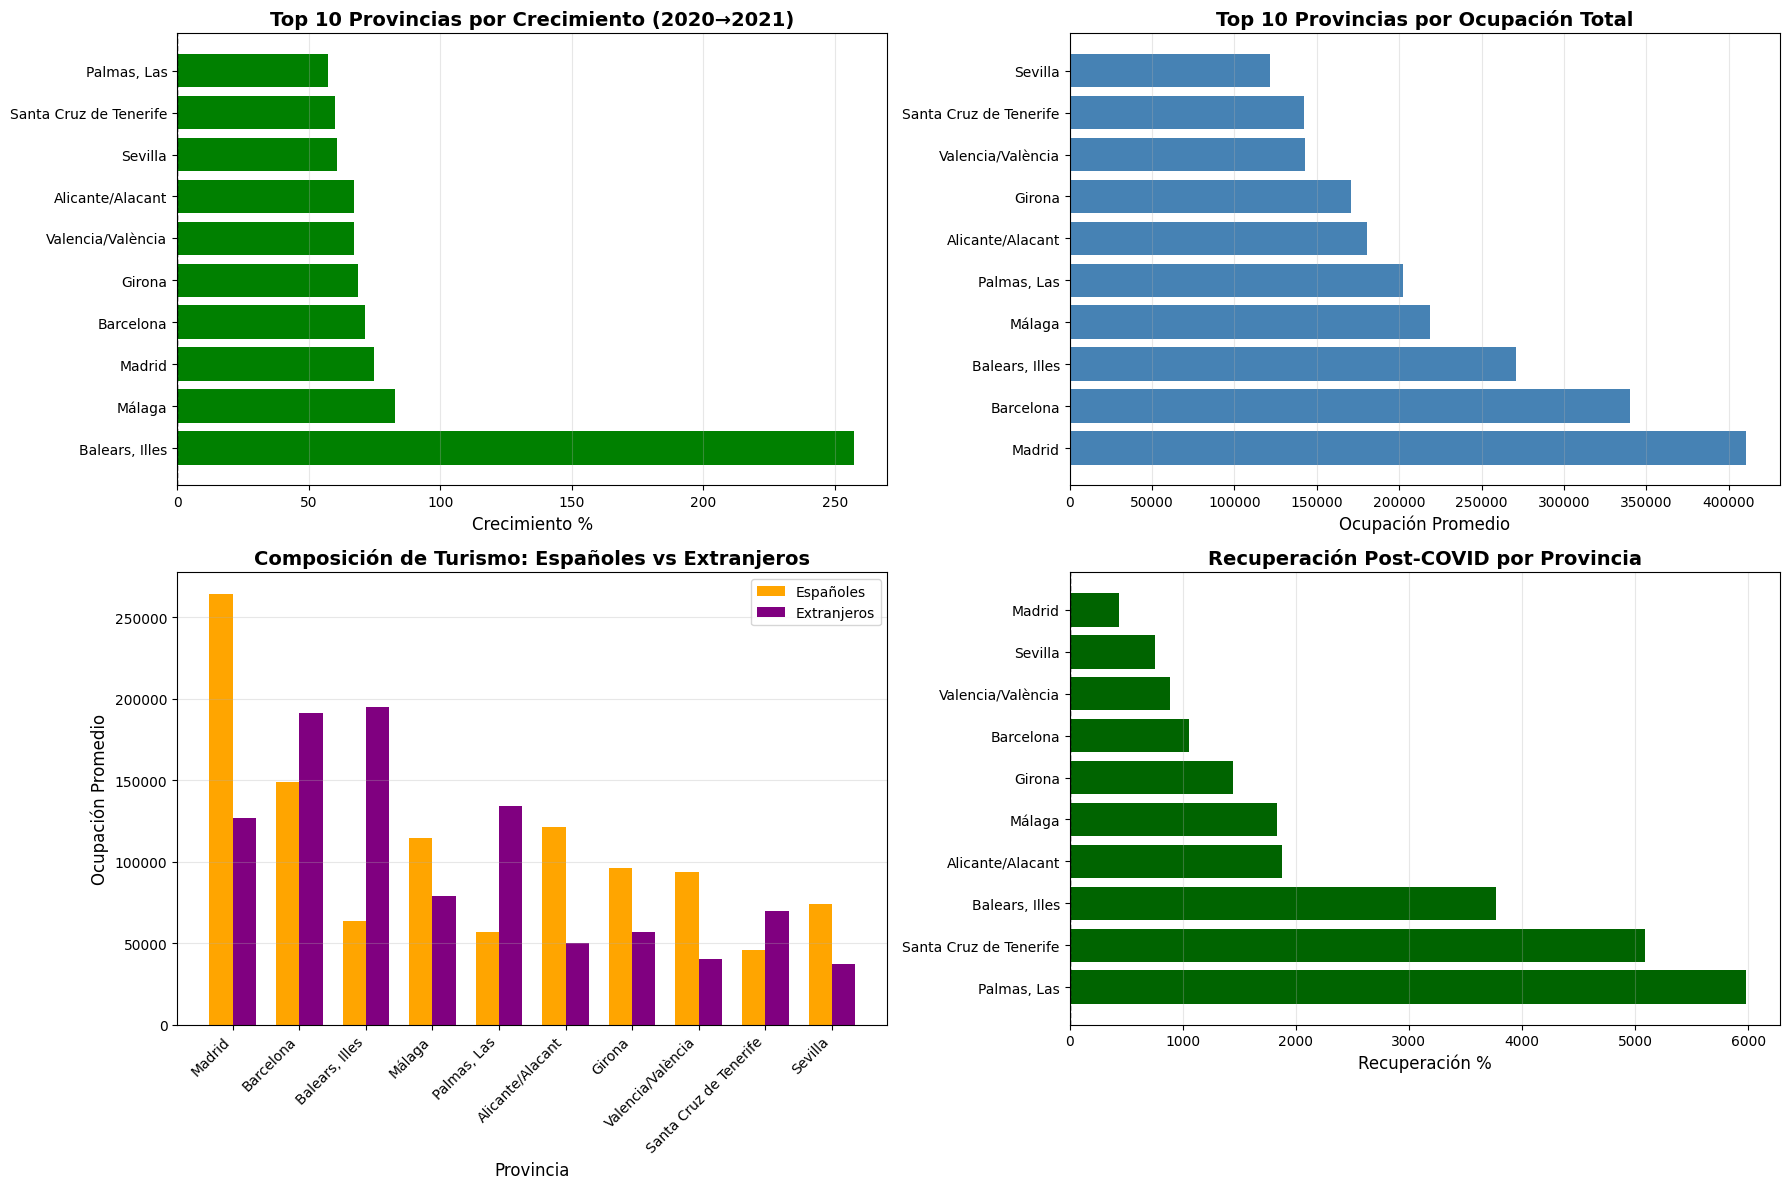

In [ ]:
# Gráfico de comparación 2020 vs 2021
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Crecimiento por provincia
ax1 = axes[0, 0]
top_10_crecimiento = comparacion_años_sorted.head(10)
colores = ['green' if x > 0 else 'red' for x in top_10_crecimiento['Crecimiento_%']]
ax1.barh(top_10_crecimiento.index, top_10_crecimiento['Crecimiento_%'], color=colores)
ax1.set_xlabel('Crecimiento %', fontsize=12)
ax1.set_title('Top 10 Provincias por Crecimiento (2020→2021)', fontsize=14, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.grid(axis='x', alpha=0.3)

# 2. Ocupación total promedio por provincia
ax2 = axes[0, 1]
ocupacion_total = df_ine.groupby('provincia')['INE_total'].mean().sort_values(ascending=False).head(10)
ax2.barh(ocupacion_total.index, ocupacion_total.values, color='steelblue')
ax2.set_xlabel('Ocupación Promedio', fontsize=12)
ax2.set_title('Top 10 Provincias por Ocupación Total', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 3. Composición españoles vs extranjeros (Top 10)
ax3 = axes[1, 0]
top_10_ocupacion = composicion.nlargest(10, 'INE_total')
x = range(len(top_10_ocupacion))
width = 0.35
ax3.bar([i - width/2 for i in x], top_10_ocupacion['INE_res_esp'], width, label='Españoles', color='orange')
ax3.bar([i + width/2 for i in x], top_10_ocupacion['INE_res_ext'], width, label='Extranjeros', color='purple')
ax3.set_xlabel('Provincia', fontsize=12)
ax3.set_ylabel('Ocupación Promedio', fontsize=12)
ax3.set_title('Composición de Turismo: Españoles vs Extranjeros', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(top_10_ocupacion.index, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Recuperación post-COVID
ax4 = axes[1, 1]
top_recuperacion = recuperacion.head(10)
colores_recup = ['darkgreen' if x > 0 else 'darkred' for x in top_recuperacion['Recuperacion_%']]
ax4.barh(top_recuperacion.index, top_recuperacion['Recuperacion_%'], color=colores_recup)
ax4.set_xlabel('Recuperación %', fontsize=12)
ax4.set_title('Recuperación Post-COVID por Provincia', fontsize=14, fontweight='bold')
ax4.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

#### Consultas base de datos propia (df)

In [15]:
# --- 2. AGRUPACIÓN GEOGRÁFICA ---

df["city_grouped"] = df["city"].replace({
    "Mallorca": "Islas Baleares",
    "Menorca": "Islas Baleares"
})

# --- 3. NORMALIZACIÓN TEMPORAL ---

df["insert_date"] = pd.to_datetime(
    df["insert_date"],
    format="%d/%m/%Y",
    errors="coerce"
)

df["year"] = df["insert_date"].dt.year
df["month_num"] = df["insert_date"].dt.month

# Meses en español
mes_es = {
    1: 'ENE', 2: 'FEB', 3: 'MAR', 4: 'ABR',
    5: 'MAY', 6: 'JUN', 7: 'JUL', 8: 'AGO',
    9: 'SEP', 10: 'OCT', 11: 'NOV', 12: 'DIC'
}

df["month"] = df["month_num"].map(mes_es)

# --- 4. FILTRAR SOLO 2020 (para comparar con INE 2020) ---

df_2020 = df[df["year"] == 2020].copy()

# --- 5. CREAR OCUPACIÓN PROXY ---

df_2020["ocupacion_proxy"] = 1 - (df_2020["availability_365"] / 365)

df_2020["ocupacion_%"] = (df_2020["ocupacion_proxy"] * 100).round(1)

#### Oferta vs. Ocupación por mes

In [17]:
# 1. Agrupamos por mes para tener la foto general de la empresa
tabla_ejecutiva = df_2020.groupby('month_num').agg(
    Oferta_Total=('unique_id', 'count'),
    Ocupacion_Media=('ocupacion_%', 'mean')
).reset_index()

# 2. Añadimos el nombre del mes
meses_nombres = ['ENE', 'FEB', 'MAR', 'ABR', 'MAY', 'JUN', 'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
tabla_ejecutiva['Mes'] = meses_nombres

# 3. Formateamos para que quede limpia
tabla_ejecutiva = tabla_ejecutiva[['Mes', 'Oferta_Total', 'Ocupacion_Media']].round(1)

print(tabla_ejecutiva)

    Mes  Oferta_Total  Ocupacion_Media
0   ENE           295             47.7
1   FEB           294             49.6
2   MAR           296             49.6
3   ABR           278             46.1
4   MAY           316             45.7
5   JUN           310             48.1
6   JUL           124             52.4
7   AGO           193             49.6
8   SEP           189             50.4
9   OCT           252             47.0
10  NOV           274             46.6
11  DIC           265             50.4


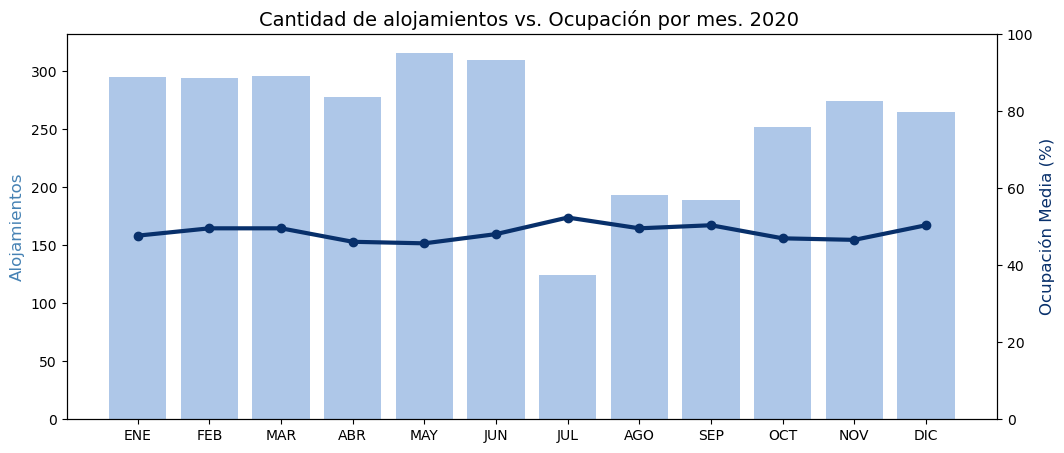

In [18]:

fig, ax1 = plt.subplots(figsize=(12, 5))

# Barras para la Oferta Total
color_barras = '#AEC7E8'
ax1.bar(tabla_ejecutiva['Mes'], tabla_ejecutiva['Oferta_Total'], color=color_barras, label='Oferta (Nº Pisos)')
ax1.set_ylabel('Alojamientos', color='steelblue', fontsize=12)

# Línea para la Ocupación Proxy
ax2 = ax1.twinx()
ax2.plot(tabla_ejecutiva['Mes'], tabla_ejecutiva['Ocupacion_Media'], color='#08306B', marker='o', linewidth=3, label='Ocupación %')
ax2.set_ylabel('Ocupación Media (%)', color='#08306B', fontsize=12)
ax2.set_ylim(0, 100) # Importante para ver la realidad del 52%

plt.title('Cantidad de alojamientos vs. Ocupación por mes. 2020 ', fontsize=14)
plt.show()

Ocupación vs Alojamientos JUN - JUL 2020

In [19]:

meses_criticos = [6, 7]
df_verano = df_2020[df_2020['month_num'].isin(meses_criticos)]

# Creamos la tabla comparativa
zoom_verano = df_verano.pivot_table(
    index='city_grouped', 
    columns='month_num', 
    values=['unique_id', 'ocupacion_%'], 
    aggfunc={'unique_id': 'count', 'ocupacion_%': 'mean'}
).round(1)

# Renombrar columnas para que se entienda
zoom_verano.columns = ['Ocupación JUN', 'Ocupación JUL', 'Pisos JUN', 'Pisos JUL']
print(zoom_verano)

                Ocupación JUN  Ocupación JUL  Pisos JUN  Pisos JUL
city_grouped                                                      
Barcelona                45.8           43.9       63.0       63.0
Girona                   47.4            NaN       61.0        NaN
Islas Baleares           38.3            NaN       65.0        NaN
Madrid                   60.4           61.2       59.0       61.0
Malaga                   43.0            NaN       15.0        NaN
Sevilla                  46.7            NaN       18.0        NaN
Valencia                 55.3            NaN       29.0        NaN
